## *Operation Note*

*01_Etherpad(ep_weave)構築.ipynb で構築したep_weaveの運用Notebookです。*

# マシンへの接続

すでに *01_Etherpad(ep_weave)構築.ipynb* を実行していれば、 `hosts` というファイル(Ansible Inventory)ができているはずです。
これを使って当該マシンにアクセスすることができます。

In [1]:
%env ANSIBLE_INVENTORY=./hosts
target_group = 'epweave0001'
!ansible -m ping {target_group}

env: ANSIBLE_INVENTORY=./hosts
57.183.73.254 | SUCCESS => {
    "changed": false,
    "ping": "pong"
}


# 実行中コンテナの確認

何かサービスへの接続異常などが生じた場合は、コンテナの実行状態を確認することで何かわかる可能性があります。

In [2]:
# 構築時に指定したデプロイ先ディレクトリ
ep_dir = '/opt/ep_weave'

!ansible -b -a 'chdir={ep_dir} docker compose ps' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
NAME                    IMAGE               COMMAND                  SERVICE      CREATED          STATUS                    PORTS
ep_weave-etherpad-1     ep_weave-etherpad   "docker-entrypoint.s…"   etherpad     45 minutes ago   Up 45 minutes (healthy)   0.0.0.0:9001->9001/tcp, [::]:9001->9001/tcp
ep_weave-postgresql-1   postgres:15         "docker-entrypoint.s…"   postgresql   46 minutes ago   Up 45 minutes             5432/tcp
ep_weave-solr-1         ep_weave-solr       "/bin/sh -c /opt/ep_…"   solr         46 minutes ago   Up 45 minutes             8983/tcptime="2025-06-18T01:34:50Z" level=warning msg="/opt/ep_weave/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion"


# ログの確認

特定の機能においてエラーが生じるといった場合は、ログを参照することでヒントが掴める場合もあります。

In [3]:
!ansible -b -a 'chdir={ep_dir} docker compose logs etherpad' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
etherpad-1  | 
etherpad-1  | > etherpad@2.3.0 prod /opt/etherpad-lite
etherpad-1  | > pnpm --filter ep_etherpad-lite run prod
etherpad-1  | 
etherpad-1  | 
etherpad-1  | > ep_etherpad-lite@2.3.0 prod /opt/etherpad-lite/src
etherpad-1  | > cross-env NODE_ENV=production node --require tsx/cjs node/server.ts
etherpad-1  | 
etherpad-1  | [2025-06-18T00:48:56.730] [INFO] settings - All relative paths will be interpreted relative to the identified Etherpad base dir: /opt/etherpad-lite
etherpad-1  | [2025-06-18T00:48:56.763] [INFO] settings - settings loaded from: /opt/etherpad-lite/settings.json
etherpad-1  | [2025-06-18T00:48:56.765] [INFO] settings - No credentials file found in /opt/etherpad-lite/credentials.json. Ignoring.
etherpad-1  | [2025-06-18T00:48:56.766] [WARN] settings - loglevel: debug
etherpad-1  | [2025-06-18T00:48:56.766] [WARN] settings - logLayoutType: colored
etherpad-1  | [2025-06-18T00:48:56.767] [INFO] settings - Using skin "colibris" 

Ansibleでの実行はリアルタイムで結果が変化する場合などは不便です。そんな時はTerminalから実行します。

Terminalを開き...

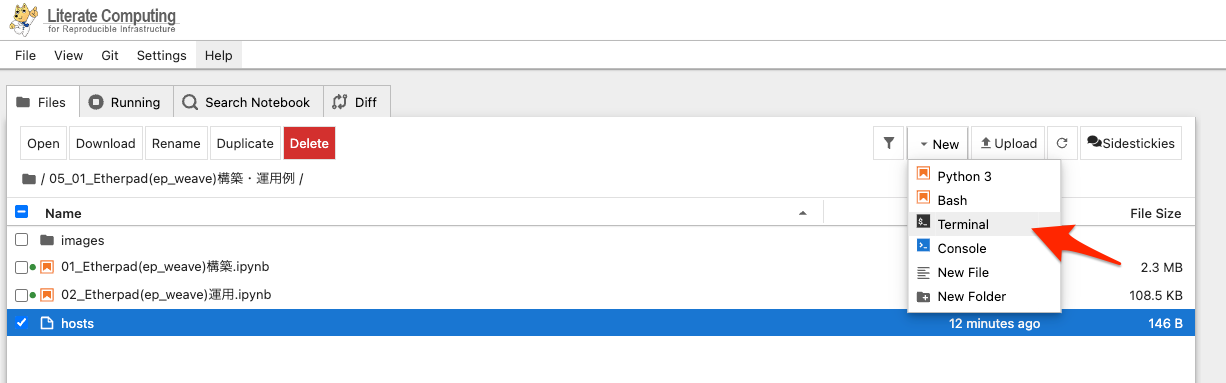

以下のコマンドをTerminalに貼り付けてください。自動的にログが記録され、Notebookに貼り付けられます。

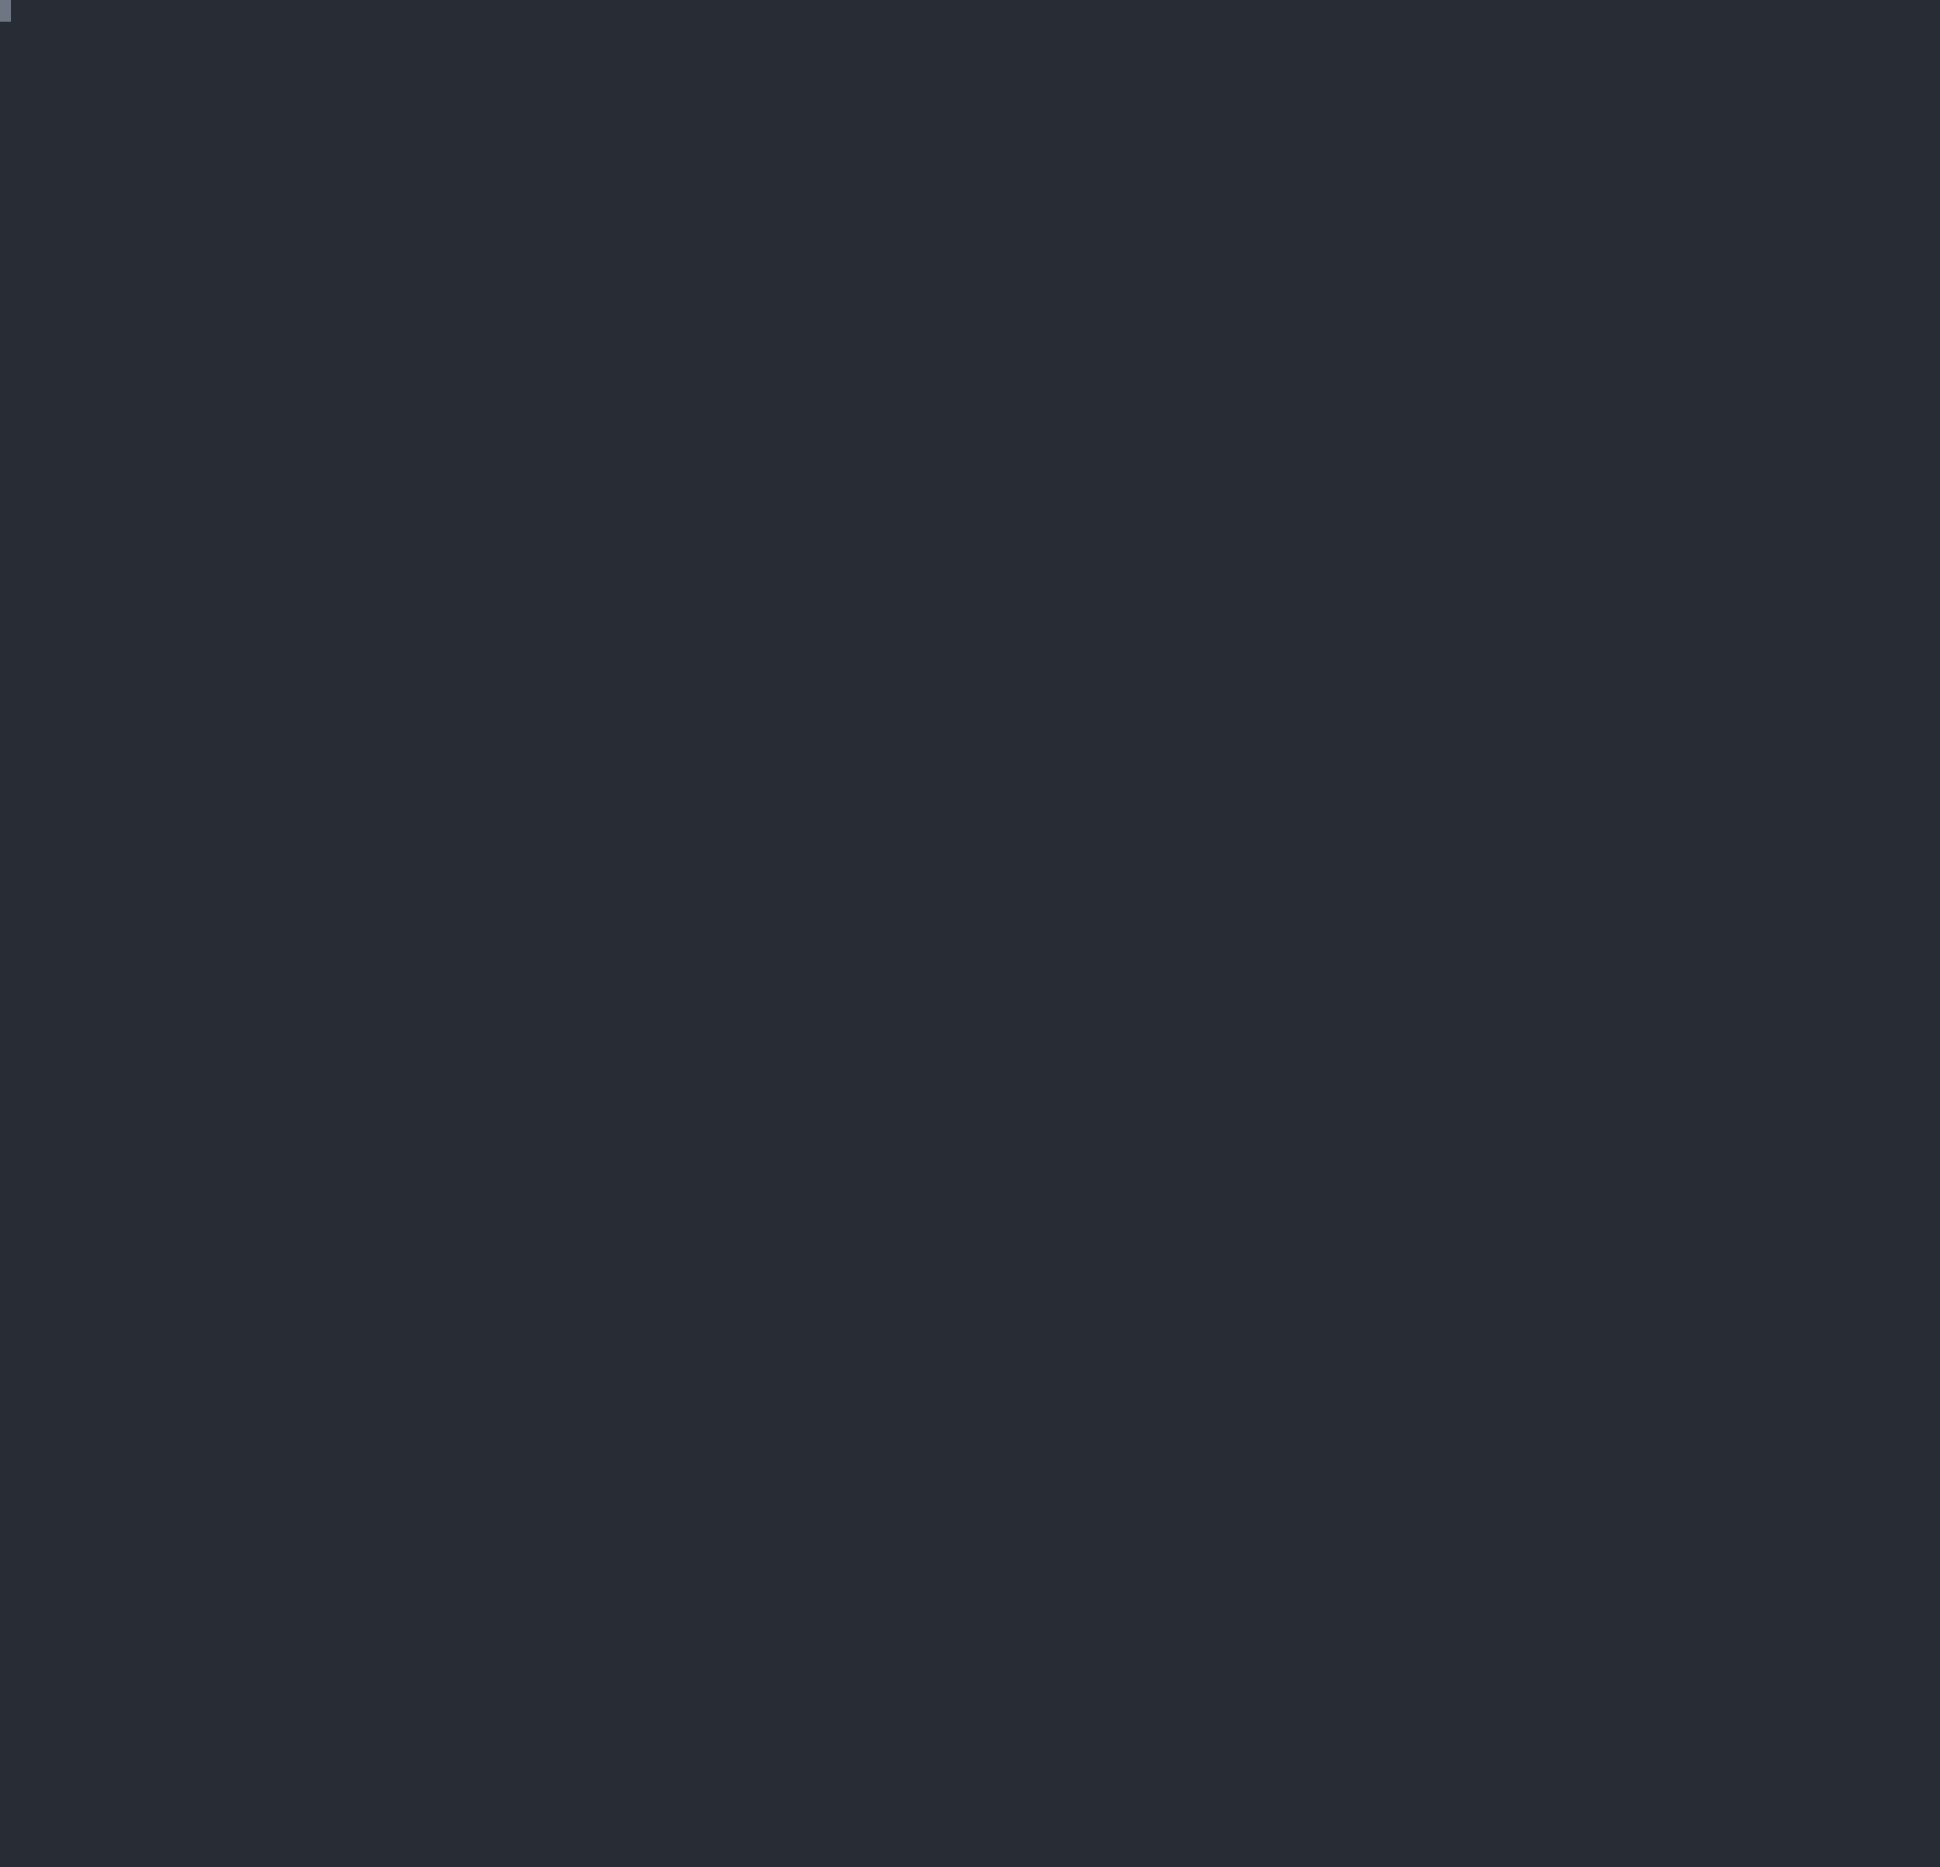

In [7]:
import os
from uuid import uuid4
from IPython.display import SVG
assert os.path.exists('.log')
file_id = str(uuid4())
asciinema_cmd = f'asciinema rec .log/{file_id}.cast'
result = input(prompt=f"Terminalを記録します。 `{asciinema_cmd}` を実行し、作業が完了したらTerminalで `exit` し、こちらに ok と入力してください。").strip().lower()
assert result == 'ok', result
!svg-term --in .log/{file_id}.cast --out .log/{file_id}.svg
SVG(filename=f'.log/{file_id}.svg')

上記の例では、ログを`docker compose logs -f` で流しながら、クライアントブラウザからログを見ています。